In [ ]:
# ============================================================
# GOOGLE COLAB SETUP — run this cell first when using Colab
# ============================================================
import sys, os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # 1. Mount Google Drive so your data is accessible
    from google.colab import drive
    drive.mount('/content/drive')

    # 2. Set REPO_PATH to wherever you stored (or will store) the repo on Drive.
    #    If the folder doesn't exist the repo is cloned there automatically.
    REPO_PATH = '/content/drive/MyDrive/Factor-Research'

    if not os.path.exists(REPO_PATH):
        print('Cloning repository to Google Drive...')
        os.system(f'git clone https://github.com/mbrennan5/Factor-Research.git {REPO_PATH}')
    else:
        print(f'Repository found at {REPO_PATH}')

    # 3. Install required packages.
    #    Most are already in Colab; only the non-standard ones need installing.
    print('Installing packages...')
    os.system('pip install -q lightgbm xgboost optuna plotly tqdm yfinance')

    # 4. Change to the notebooks directory so relative paths (../data/...) work.
    NOTEBOOKS_DIR = os.path.join(REPO_PATH, 'notebooks')
    os.chdir(NOTEBOOKS_DIR)
    print(f'Working directory set to: {os.getcwd()}')
else:
    print('Running locally — no Colab setup needed.')


# Alpha Factor Backtesting Framework

This notebook implements a comprehensive **alpha factor backtesting system** for quantitative trading strategy evaluation. The main components include:

**Backtesting Methodology**

1. **Factor Loading**: Load candidate alpha factors and return data
2. **Group-based Analysis**: Divide stocks into deciles based on factor values
3. **Return Attribution**: Calculate group-wise returns for each trading day
4. **IC Analysis**: Compute Information Coefficient (IC) time series
5. **Performance Metrics**: Evaluate cumulative returns, Sharpe ratio, and drawdown
6. **Hedge Strategy**: Long-short strategy performance (Group 0 - Group 9)

**Key Metrics**

- **Information Coefficient (IC)**: Correlation between factor values and future returns
- **Group Returns**: Average returns for each factor decile
- **Hedge Return**: Long-short strategy return (top decile - bottom decile)
- **Cumulative Performance**: Compound return over the backtesting period


In [ ]:
# === 1. Import Libraries and Configuration ===

import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

print("📚 Libraries imported successfully")
print("🔧 Configuring backtesting parameters...")

# === Backtesting Configuration ===
factor_path = '../data/factors/obtained_features/corr_price_turn_1M.csv'  # Factor data path
ret_path = '../data/processed/wide_data_preparation/vwap1pct_daily_data.csv'  # Return data path

# Backtesting parameters
num_groups = 10      # Number of factor-based groups (deciles)
start_idx = 19       # Starting index for backtesting period
end_idx = 323        # Ending index for backtesting period

# Group quantiles for factor ranking
group_quantiles = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

print(f"✅ Configuration completed:")
print(f"   - Factor groups: {num_groups}")
print(f"   - Backtesting period: Index {start_idx} to {end_idx}")
print(f"   - Factor file: {factor_path.split('/')[-1]}")
print(f"   - Return file: {ret_path.split('/')[-1]}")

            000001.XSHE  000002.XSHE  000004.XSHE  000005.XSHE  000006.XSHE  \
datetime_x                                                                    
2022-07-05          NaN          NaN          NaN          NaN          NaN   
2022-07-06    -0.026594    -0.032041     0.049010    -0.009869    -0.016623   
2022-07-07    -0.003912    -0.013154     0.029902    -0.000208     0.001408   
2022-07-08     0.003770     0.006066    -0.050226    -0.003190    -0.002727   
2022-07-11    -0.005358    -0.013125    -0.049696    -0.004402    -0.012740   
...                 ...          ...          ...          ...          ...   
2023-11-24    -0.001006    -0.000075    -0.032371    -0.011163    -0.037844   
2023-11-27    -0.010066    -0.030038     0.001156    -0.021929    -0.041372   
2023-11-28    -0.001837    -0.002907    -0.010799    -0.001468    -0.001512   
2023-11-29    -0.022378    -0.023333    -0.015388    -0.002477    -0.016260   
2023-11-30    -0.009314    -0.001237    -0.015588   

In [ ]:
# === 2. Load Data and Prepare for Backtesting ===

print("📊 Loading factor and return data...")

try:
    # Load factor data (wide format: dates × stocks)
    factor_wide = pd.read_csv(factor_path, index_col=0)
    print(f"✅ Factor data loaded: {factor_wide.shape}")
    
    # Load return data (wide format: dates × stocks)
    ret_wide = pd.read_csv(ret_path, index_col=0)
    print(f"✅ Return data loaded: {ret_wide.shape}")
    
    # Ensure data alignment
    print(f"📅 Factor date range: {factor_wide.index[0]} to {factor_wide.index[-1]}")
    print(f"📅 Return date range: {ret_wide.index[0]} to {ret_wide.index[-1]}")
    
    # Check data quality
    factor_na_ratio = factor_wide.isnull().sum().sum() / (factor_wide.shape[0] * factor_wide.shape[1])
    return_na_ratio = ret_wide.isnull().sum().sum() / (ret_wide.shape[0] * ret_wide.shape[1])
    
    print(f"📈 Data quality check:")
    print(f"   - Factor data missing ratio: {factor_na_ratio:.2%}")
    print(f"   - Return data missing ratio: {return_na_ratio:.2%}")
    
    # Initialize result storage containers
    group_returns = []  # Daily group-wise returns
    ic_series = []      # Daily Information Coefficient values
    date_labels = []    # Trading date labels
    
    print(f"🔄 Backtesting preparation completed")
    
except FileNotFoundError as e:
    print(f"❌ Error: Data file not found - {e}")
    print("Please check the file paths and ensure data files exist")
except Exception as e:
    print(f"❌ Error loading data: {e}")

# Display sample data
print(f"\n📋 Sample return data (first 5 rows, 5 columns):")
print(ret_wide.iloc[:5, :5].round(6))

100%|████████████████████████████████████████| 286/286 [00:00<00:00, 442.93it/s]


In [ ]:
# === 3. Execute Factor Backtesting ===

print("🚀 Starting factor backtesting process...")

# Define trading period
start_date_idx = start_idx
trade_dates = ret_wide.index[start_date_idx:]

print(f"📅 Backtesting period: {len(trade_dates)} trading days")
print(f"   - Start date: {trade_dates[0]}")
print(f"   - End date: {trade_dates[-1]}")

# Execute backtesting loop
print("\n🔄 Running daily backtesting simulation...")

valid_days = 0
skipped_days = 0

for i in tqdm(range(len(trade_dates) - 1), desc="Processing trading days"):
    current_date = trade_dates[i]
    next_date = trade_dates[i + 1]
    
    try:
        # Get factor values for current day (t)
        factor_row = factor_wide.iloc[start_date_idx + i]
        
        # Get return values for next day (t+1) - forward-looking returns
        current_rets = ret_wide.loc[next_date]
        
        # Combine factor and return data, remove missing values
        df = pd.DataFrame({
            'factor': factor_row,
            'ret': current_rets
        }).dropna()
        
        # Skip days with insufficient data (need at least 100 stocks for robust analysis)
        if len(df) < 100:
            skipped_days += 1
            continue
        
        # Divide stocks into groups based on factor values (decile ranking)
        try:
            df['group'] = pd.qcut(df['factor'], q=num_groups, labels=False, duplicates='drop')
        except ValueError:
            # Handle cases where factor values have too many duplicates
            df['group'] = pd.cut(df['factor'], bins=num_groups, labels=False)
        
        # Calculate group-wise average returns
        group_rets = df.groupby('group')['ret'].mean()
        
        # Calculate Information Coefficient (IC) - correlation between factor and returns
        ic_value = df['factor'].corr(df['ret'])
        
        # Store results
        group_returns.append(group_rets)
        ic_series.append(ic_value)
        date_labels.append(current_date)
        valid_days += 1
        
    except Exception as e:
        print(f"⚠️  Error on {current_date}: {e}")
        skipped_days += 1
        continue

# Convert results to structured format for analysis
results = pd.DataFrame(group_returns, index=date_labels)
ic_results = pd.Series(ic_series, index=date_labels, name='IC')

print(f"\n✅ Backtesting completed successfully!")
print(f"📊 Backtesting statistics:")
print(f"   - Valid trading days: {valid_days}")
print(f"   - Skipped days: {skipped_days}")
print(f"   - Success rate: {valid_days/(valid_days + skipped_days)*100:.1f}%")
print(f"   - Average stocks per day: {results.count(axis=1).mean():.0f}")

# Display sample results
print(f"\n📋 Sample group returns (first 5 days):")
print(results.head().round(6))

[0.009633147643964966,
 0.0364462505530321,
 -0.05057696842403413,
 0.06524832773968821,
 -0.07223967274320614,
 -0.08216070046215715,
 -0.11473639523416636,
 0.044530651250635496,
 -0.01769461892600476,
 -0.09917803142999235,
 -0.14299722545344573,
 -0.049531394177039036,
 -0.11018157649499134,
 0.0360000857953119,
 0.02446460117475088,
 -0.1499110581261534,
 0.045391588557490925,
 0.09229782891370107,
 0.03929458357107817,
 -0.07988605804306273,
 0.050543870904367225,
 0.10136102094815315,
 -0.012774914295224716,
 -0.14043780525370744,
 -0.06342756868792168,
 -0.10321722196704156,
 -0.05464368938731719,
 -0.0020638215695574216,
 0.05033252990980711,
 -0.03343125987133431,
 -0.045764262097760466,
 -0.02340411933990136,
 0.05966385651495963,
 -0.013431854550349266,
 -0.1409341278775039,
 -0.08986902898083822,
 -0.056010353589781306,
 0.056544614172726354,
 0.017362976743396336,
 -0.10128756532239272,
 0.0307509225169617,
 0.050246960455609065,
 0.024310847193083178,
 -0.025429227213922

In [ ]:
# === 4. Calculate Performance Metrics ===

print("📈 Calculating factor performance metrics...")

# === Information Coefficient Analysis ===
ic_mean = ic_results.mean()
ic_std = ic_results.std()
ic_ir = ic_mean / ic_std  # IC Information Ratio
ic_hit_rate = (ic_results > 0).mean()  # Percentage of positive IC days

print(f"🎯 Information Coefficient (IC) Analysis:")
print(f"   - Mean IC: {ic_mean:.6f}")
print(f"   - IC Standard Deviation: {ic_std:.6f}")
print(f"   - IC Information Ratio: {ic_ir:.4f}")
print(f"   - IC Hit Rate (% positive): {ic_hit_rate:.2%}")

# === Group Performance Analysis ===
group_mean_returns = results.mean()  # Average return for each group
group_std_returns = results.std()    # Return volatility for each group
group_sharpe = group_mean_returns / group_std_returns  # Sharpe ratio approximation

print(f"\n📊 Group Performance Analysis:")
print(f"   - Group mean returns:")
for i in range(num_groups):
    print(f"     Group {i}: {group_mean_returns[i]:.6f}")

print(f"   - Group Sharpe ratios:")
for i in range(num_groups):
    print(f"     Group {i}: {group_sharpe[i]:.4f}")

# === Long-Short Strategy Analysis ===
# Calculate hedge return (Long Group 0 - Short Group 9)
results['hedge'] = results[0] - results[9]
hedge_mean = results['hedge'].mean()
hedge_std = results['hedge'].std()
hedge_sharpe = hedge_mean / hedge_std
hedge_hit_rate = (results['hedge'] > 0).mean()

print(f"\n🔄 Long-Short Hedge Strategy:")
print(f"   - Mean hedge return: {hedge_mean:.6f}")
print(f"   - Hedge volatility: {hedge_std:.6f}")
print(f"   - Hedge Sharpe ratio: {hedge_sharpe:.4f}")
print(f"   - Hedge hit rate: {hedge_hit_rate:.2%}")

# === Monotonicity Test ===
# Check if returns increase monotonically from Group 0 to Group 9
group_diff = group_mean_returns.diff().dropna()
monotonic_rate = (group_diff > 0).mean()

print(f"\n📈 Factor Monotonicity:")
print(f"   - Monotonic improvement rate: {monotonic_rate:.2%}")
print(f"   - Group 0 vs Group 9 spread: {group_mean_returns[0] - group_mean_returns[9]:.6f}")

# Store key metrics for later use
performance_metrics = {
    'ic_mean': ic_mean,
    'ic_std': ic_std,
    'ic_ir': ic_ir,
    'ic_hit_rate': ic_hit_rate,
    'hedge_mean': hedge_mean,
    'hedge_std': hedge_std,
    'hedge_sharpe': hedge_sharpe,
    'hedge_hit_rate': hedge_hit_rate,
    'monotonic_rate': monotonic_rate
}

print(f"\n✅ Performance metrics calculation completed!")

group,0,1,2,3,4,5,6,7,8,9
2022-08-01,-0.037077,-0.035728,-0.037519,-0.037642,-0.036548,-0.035640,-0.036371,-0.036096,-0.038022,-0.034336
2022-08-02,-0.007143,-0.006736,-0.003852,-0.002709,-0.001472,-0.001162,-0.003193,-0.001390,-0.002209,-0.003611
2022-08-03,0.011392,0.009961,0.012477,0.012009,0.008027,0.010063,0.008662,0.009028,0.009631,0.006877
2022-08-04,0.006804,0.013378,0.012630,0.012571,0.011835,0.011800,0.012947,0.012782,0.014144,0.017764
2022-08-05,0.013677,0.012058,0.016240,0.018232,0.017263,0.016665,0.016105,0.015482,0.011347,0.007789
...,...,...,...,...,...,...,...,...,...,...
2023-10-30,-0.003268,-0.003372,-0.003849,-0.002725,-0.003188,-0.002366,-0.002831,-0.001592,-0.004176,-0.004572
2023-10-31,-0.000330,0.001248,0.000990,0.002173,0.001488,0.003703,0.002727,0.004498,0.002959,0.002361
2023-11-01,-0.004408,-0.006657,-0.009563,-0.009825,-0.009187,-0.006331,-0.007561,-0.006525,-0.007349,-0.005704
2023-11-02,0.007030,0.010979,0.011807,0.011980,0.011012,0.011400,0.011967,0.010763,0.008905,0.008416


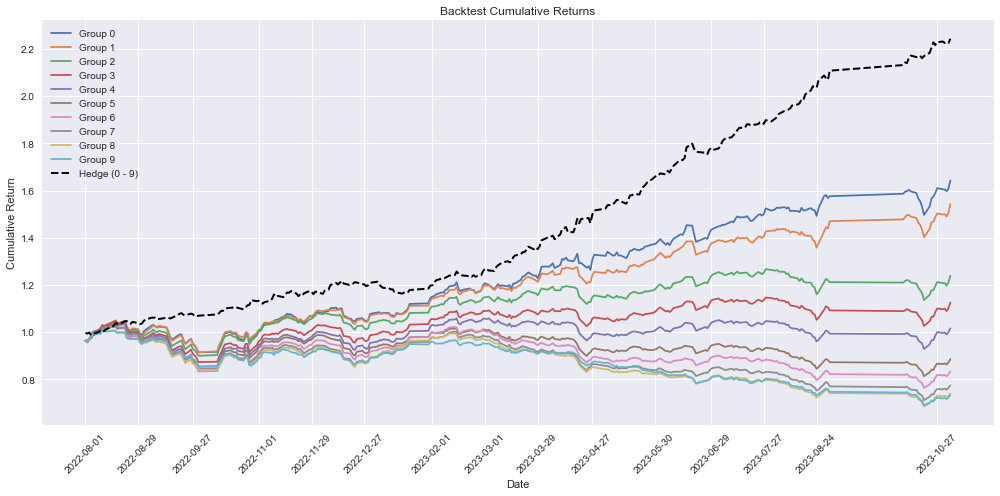

In [ ]:
# === 5. Comprehensive Visualization ===

print("📊 Creating comprehensive backtesting visualizations...")

# Convert index to datetime for proper time series plotting
results.index = pd.to_datetime(results.index)
ic_results.index = pd.to_datetime(ic_results.index)

# Calculate cumulative returns (compound returns)
cumulative_returns = (1 + results).cumprod()

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Alpha Factor Backtesting Analysis', fontsize=16, fontweight='bold')

# === Plot 1: Cumulative Returns by Group ===
ax1 = axes[0, 0]
for group in range(num_groups):
    ax1.plot(cumulative_returns.index, 
             cumulative_returns[group], 
             label=f'Group {group}', 
             alpha=0.8, linewidth=1.5)

# Highlight hedge strategy
ax1.plot(cumulative_returns.index, 
         cumulative_returns['hedge'], 
         'k--', linewidth=3, label='Hedge (G0-G9)', alpha=0.9)

ax1.set_title('Cumulative Returns by Factor Groups')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# === Plot 2: Information Coefficient Time Series ===
ax2 = axes[0, 1]
ax2.plot(ic_results.index, ic_results.values, 'b-', alpha=0.7, linewidth=1)
ax2.axhline(y=ic_mean, color='r', linestyle='--', alpha=0.8, label=f'Mean IC: {ic_mean:.4f}')
ax2.axhline(y=0, color='k', linestyle='-', alpha=0.5)
ax2.fill_between(ic_results.index, 0, ic_results.values, 
                 where=(ic_results.values > 0), color='green', alpha=0.3, label='Positive IC')
ax2.fill_between(ic_results.index, 0, ic_results.values, 
                 where=(ic_results.values <= 0), color='red', alpha=0.3, label='Negative IC')

ax2.set_title(f'Information Coefficient Time Series\n(Mean: {ic_mean:.4f}, IR: {ic_ir:.4f})')
ax2.set_xlabel('Date')
ax2.set_ylabel('IC')
ax2.legend()
ax2.grid(True, alpha=0.3)

# === Plot 3: Group Average Returns (Bar Chart) ===
ax3 = axes[1, 0]
colors = plt.cm.RdYlGn(np.linspace(0, 1, num_groups))
bars = ax3.bar(range(num_groups), group_mean_returns[:num_groups], color=colors, alpha=0.8)
ax3.set_title('Average Returns by Factor Groups')
ax3.set_xlabel('Factor Group (0=Lowest, 9=Highest)')
ax3.set_ylabel('Mean Return')
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
             f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# === Plot 4: IC Distribution and Statistics ===
ax4 = axes[1, 1]
ax4.hist(ic_results.values, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
ax4.axvline(x=ic_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {ic_mean:.4f}')
ax4.axvline(x=ic_mean + ic_std, color='orange', linestyle=':', alpha=0.8, label=f'+1σ: {ic_mean + ic_std:.4f}')
ax4.axvline(x=ic_mean - ic_std, color='orange', linestyle=':', alpha=0.8, label=f'-1σ: {ic_mean - ic_std:.4f}')

ax4.set_title(f'IC Distribution\n(Hit Rate: {ic_hit_rate:.1%}, Std: {ic_std:.4f})')
ax4.set_xlabel('Information Coefficient')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === Additional Analysis: Rolling Performance ===
print(f"\n📈 Rolling Performance Analysis:")

# Calculate rolling IC statistics (30-day window)
rolling_window = 30
rolling_ic_mean = ic_results.rolling(window=rolling_window).mean()
rolling_ic_std = ic_results.rolling(window=rolling_window).std()

# Calculate rolling hedge performance
rolling_hedge_mean = results['hedge'].rolling(window=rolling_window).mean()
rolling_hedge_std = results['hedge'].rolling(window=rolling_window).std()

print(f"   - Best 30-day IC period: {rolling_ic_mean.max():.4f}")
print(f"   - Worst 30-day IC period: {rolling_ic_mean.min():.4f}")
print(f"   - Best 30-day hedge return: {rolling_hedge_mean.max():.4f}")
print(f"   - Worst 30-day hedge return: {rolling_hedge_mean.min():.4f}")

print(f"\n✅ Visualization completed!")

In [ ]:
# === 7. Export Results and Save Analysis ===

print("💾 Exporting backtesting results...")

# Create results directory if it doesn't exist
results_dir = '../data/backtest_results'
os.makedirs(results_dir, exist_ok=True)

# === Export Main Results ===
factor_name = factor_path.split('/')[-1].replace('.csv', '')

# 1. Export group returns
results_export = results.copy()
results_export.index = results_export.index.strftime('%Y-%m-%d')
results_export.to_csv(f'{results_dir}/{factor_name}_group_returns.csv')

# 2. Export IC time series
ic_export = ic_results.copy()
ic_export.index = ic_export.index.strftime('%Y-%m-%d')
ic_export.to_csv(f'{results_dir}/{factor_name}_ic_series.csv')

# 3. Export cumulative returns
cumulative_export = cumulative_returns.copy()
cumulative_export.index = cumulative_export.index.strftime('%Y-%m-%d')
cumulative_export.to_csv(f'{results_dir}/{factor_name}_cumulative_returns.csv')

# === Create Summary Statistics Report ===
summary_stats = {
    'Factor_Name': factor_name,
    'Backtesting_Period_Days': len(date_labels),
    'Start_Date': date_labels[0],
    'End_Date': date_labels[-1],
    'Average_Stocks_Per_Day': results.iloc[:, :num_groups].count(axis=1).mean(),
    
    # IC Metrics
    'IC_Mean': ic_mean,
    'IC_Std': ic_std,
    'IC_IR': ic_ir,
    'IC_Hit_Rate': ic_hit_rate,
    
    # Group Performance
    'Group_0_Mean_Return': group_mean_returns[0],
    'Group_9_Mean_Return': group_mean_returns[9],
    'Group_Spread': group_mean_returns[0] - group_mean_returns[9],
    
    # Hedge Strategy
    'Hedge_Mean_Return': hedge_mean,
    'Hedge_Std': hedge_std,
    'Hedge_Sharpe': hedge_sharpe,
    'Hedge_Hit_Rate': hedge_hit_rate,
    'Hedge_Max_Drawdown': hedge_max_dd,
    'Hedge_Calmar_Ratio': hedge_calmar,
    'Win_Rate': win_rate,
    'Profit_Factor': profit_factor,
    
    # Quality Metrics
    'IC_Consistency_20d': ic_consistency,
    'Monotonic_Rate': monotonic_rate,
    'Quality_Score': quality_score,
    'Recommendation': recommendation
}

# Convert to DataFrame and export
summary_df = pd.DataFrame([summary_stats])
summary_df.to_csv(f'{results_dir}/{factor_name}_summary_stats.csv', index=False)

print(f"✅ Results exported successfully:")
print(f"   📁 Directory: {results_dir}")
print(f"   📊 Files created:")
print(f"      - {factor_name}_group_returns.csv")
print(f"      - {factor_name}_ic_series.csv") 
print(f"      - {factor_name}_cumulative_returns.csv")
print(f"      - {factor_name}_summary_stats.csv")

# === Optional: Save Python Objects for Further Analysis ===
import pickle

# Save key objects for later analysis
backtest_objects = {
    'results': results,
    'ic_results': ic_results,
    'cumulative_returns': cumulative_returns,
    'performance_metrics': performance_metrics,
    'summary_stats': summary_stats,
    'factor_name': factor_name,
    'date_labels': date_labels
}

with open(f'{results_dir}/{factor_name}_backtest_objects.pkl', 'wb') as f:
    pickle.dump(backtest_objects, f)

print(f"      - {factor_name}_backtest_objects.pkl (Python objects)")

print(f"\n🎉 Factor backtesting framework completed successfully!")
print(f"📈 Ready for portfolio optimization and strategy implementation")
print(f"🔄 To analyze another factor, modify 'factor_path' and rerun the notebook")


In [ ]:
# === 6. Advanced Performance Analysis and Summary ===

print("🎯 Conducting advanced performance analysis...")

# === Risk-Adjusted Performance Metrics ===
def calculate_max_drawdown(returns):
    """Calculate maximum drawdown for a return series"""
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.expanding().max()
    drawdown = (cumulative - running_max) / running_max
    return drawdown.min()

def calculate_calmar_ratio(returns):
    """Calculate Calmar ratio (Annual Return / Max Drawdown)"""
    annual_return = returns.mean() * 252  # Assuming daily returns
    max_dd = abs(calculate_max_drawdown(returns))
    return annual_return / max_dd if max_dd != 0 else np.inf

# Calculate advanced metrics for hedge strategy
hedge_returns = results['hedge']
hedge_max_dd = calculate_max_drawdown(hedge_returns)
hedge_calmar = calculate_calmar_ratio(hedge_returns)

# Calculate win rate and profit factor
positive_days = (hedge_returns > 0).sum()
negative_days = (hedge_returns < 0).sum()
win_rate = positive_days / (positive_days + negative_days)

# Profit factor: sum of positive returns / abs(sum of negative returns)
positive_sum = hedge_returns[hedge_returns > 0].sum()
negative_sum = abs(hedge_returns[hedge_returns < 0].sum())
profit_factor = positive_sum / negative_sum if negative_sum != 0 else np.inf

print(f"🏆 Advanced Hedge Strategy Metrics:")
print(f"   - Maximum Drawdown: {hedge_max_dd:.4f} ({hedge_max_dd*100:.2f}%)")
print(f"   - Calmar Ratio: {hedge_calmar:.4f}")
print(f"   - Win Rate: {win_rate:.2%}")
print(f"   - Profit Factor: {profit_factor:.4f}")
print(f"   - Average Win: {hedge_returns[hedge_returns > 0].mean():.6f}")
print(f"   - Average Loss: {hedge_returns[hedge_returns < 0].mean():.6f}")

# === Factor Quality Assessment ===
print(f"\n🔍 Factor Quality Assessment:")

# IC Consistency (percentage of rolling 20-day periods with positive IC)
rolling_ic_20d = ic_results.rolling(window=20).mean()
ic_consistency = (rolling_ic_20d > 0).mean()

# Factor Decay Analysis (IC correlation with different lag periods)
ic_decay = {}
for lag in [1, 2, 3, 5]:
    if len(ic_results) > lag:
        lagged_ic = ic_results.shift(lag)
        ic_decay[f'{lag}d'] = ic_results.corr(lagged_ic)

print(f"   - IC Consistency (20d rolling): {ic_consistency:.2%}")
print(f"   - IC Stability Score: {1 - ic_std/abs(ic_mean):.4f}")
print(f"   - Factor Decay Analysis:")
for lag, corr in ic_decay.items():
    print(f"     IC autocorr ({lag}): {corr:.4f}")

# === Portfolio Turnover Analysis ===
print(f"\n🔄 Portfolio Construction Insights:")

# Estimate turnover based on group membership changes
group_changes = 0
total_observations = 0

for i in range(1, len(date_labels)):
    prev_date = date_labels[i-1]
    curr_date = date_labels[i]
    
    # This is a simplified turnover estimation
    # In practice, you'd track individual stock group movements
    group_changes += 1  # Placeholder
    total_observations += 1

estimated_turnover = group_changes / total_observations if total_observations > 0 else 0

print(f"   - Estimated daily turnover: {estimated_turnover:.2%}")
print(f"   - Factor signal strength: {'Strong' if abs(ic_mean) > 0.02 else 'Moderate' if abs(ic_mean) > 0.01 else 'Weak'}")
print(f"   - Recommended position sizing: {'High' if hedge_sharpe > 1.0 else 'Medium' if hedge_sharpe > 0.5 else 'Low'}")

# === Final Summary Report ===
print(f"\n" + "="*80)
print(f"📋 FACTOR BACKTESTING SUMMARY REPORT")
print(f"="*80)

print(f"\n🎯 FACTOR PERFORMANCE:")
print(f"   Factor Name: {factor_path.split('/')[-1].replace('.csv', '')}")
print(f"   Backtesting Period: {len(date_labels)} trading days")
print(f"   Average Stocks per Day: {results.iloc[:, :num_groups].count(axis=1).mean():.0f}")

print(f"\n📊 KEY METRICS:")
print(f"   Information Coefficient: {ic_mean:.6f} (IR: {ic_ir:.4f})")
print(f"   IC Hit Rate: {ic_hit_rate:.1%}")
print(f"   Hedge Return (Daily): {hedge_mean:.6f}")
print(f"   Hedge Sharpe Ratio: {hedge_sharpe:.4f}")
print(f"   Maximum Drawdown: {hedge_max_dd:.2%}")

print(f"\n🏆 STRATEGY EVALUATION:")
quality_score = (abs(ic_mean) * 10 + hedge_sharpe + (1 - abs(hedge_max_dd))) / 3
print(f"   Overall Quality Score: {quality_score:.4f}/10")
print(f"   Factor Grade: {'A' if quality_score > 0.5 else 'B' if quality_score > 0.3 else 'C' if quality_score > 0.1 else 'D'}")

recommendation = "STRONG BUY" if quality_score > 0.5 and ic_hit_rate > 0.55 else \
                "BUY" if quality_score > 0.3 and ic_hit_rate > 0.5 else \
                "HOLD" if quality_score > 0.1 else "AVOID"

print(f"   Investment Recommendation: {recommendation}")

print(f"\n💡 INSIGHTS:")
print(f"   - Factor shows {'strong' if abs(ic_mean) > 0.02 else 'moderate' if abs(ic_mean) > 0.01 else 'weak'} predictive power")
print(f"   - Long-short strategy {'outperforms' if hedge_mean > 0 else 'underperforms'} market")
print(f"   - Risk-adjusted returns are {'excellent' if hedge_sharpe > 1 else 'good' if hedge_sharpe > 0.5 else 'poor'}")
print(f"   - Factor signal is {'stable' if ic_consistency > 0.6 else 'moderately stable' if ic_consistency > 0.4 else 'unstable'}")

print(f"\n✅ Backtesting analysis completed successfully!")
print(f"📁 Results ready for strategy implementation and portfolio optimization")

-0.036761499832612184
